In [ ]:
print("hello world")

## Test `plot_missing_values` (eda_01)
Viet thu ham trong notebook truoc, chay on roi moi copy sang `src/02_eda.py`.

In [1]:
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Notebook chay tu thu muc notebooks/ -> chuyen ve goc du an de dung duong dan tuong doi
if Path.cwd().name == "notebooks":
    os.chdir("..")

RAW_DIR = Path("data/raw/calfire")
print(Path.cwd())

k:\TTDL


In [3]:
def plot_missing_values(df=None, output_path: Path = Path("reports/figures/eda_01_missing_values.png"), top_n: int = 12):
    """Ve bieu do phan tich ty le khuyet thieu cua cac cot du lieu bang Seaborn/Matplotlib."""
    # df: None -> doc ca 5 file tho; DataFrame -> 1 bang; dict {ten: DataFrame} -> nhieu bang
    if df is None:
        datasets = {f.stem: pd.read_csv(f, encoding="utf-8-sig", low_memory=False) for f in sorted(RAW_DIR.glob("*.csv"))}
    elif isinstance(df, pd.DataFrame):
        datasets = {"data": df}
    else:
        datasets = df

    ncols = 2 if len(datasets) > 1 else 1
    nrows = math.ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4.5 * nrows), squeeze=False)
    cmap = plt.get_cmap("OrRd")  # Sequential palette theo docs/COLOR_GUIDE.md muc 2.1

    for ax, (name, data) in zip(axes.flat, datasets.items()):
        missing_pct = data.isna().mean() * 100
        n_missing_cols = int((missing_pct > 0).sum())
        # Chi giu top_n cot thieu nhieu nhat, dao nguoc de cot thieu nhieu nhat nam tren cung
        top = missing_pct[missing_pct > 0].sort_values(ascending=False).head(top_n)[::-1]

        ax.set_title(f"{name}{len(data):,} dong | {n_missing_cols}/{data.shape[1]} cot co o trong", loc="left", fontsize=10)
        if top.empty:
            ax.text(0.5, 0.5, "Khong co o trong", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        labels = [c if len(c) <= 40 else c[:37] + "..." for c in top.index]
        ax.barh(labels, top.values, color=cmap(0.3 + 0.7 * top.values / 100))
        for y, v in enumerate(top.values):
            ax.text(v + 1, y, f"{v:.1f}%", va="center", fontsize=8)
        ax.axvline(50, color="#7F7F7F", linestyle="--", linewidth=1)  # nguong 50%: can nhac bo cot
        ax.set_xlim(0, 112)
        ax.set_xlabel("Ty le khuyet thieu (%)")
        ax.tick_params(axis="y", labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    # An cac o trong thua cua luoi subplot (vd 5 bang -> luoi 3x2 thua 1 o)
    for ax in axes.flat[len(datasets):]:
        ax.set_axis_off()

    fig.suptitle(f"Ty le khuyet thieu theo cot (top {top_n} moi bang, net dut = 50%)", fontsize=13, x=0.01, ha="left")
    fig.tight_layout()

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"[TV1 - EDA] Da luu bieu do khuyet thieu -> {output_path}")
    return fig

[TV1 - EDA] Da luu bieu do khuyet thieu -> reports\figures\eda_01_missing_values.png


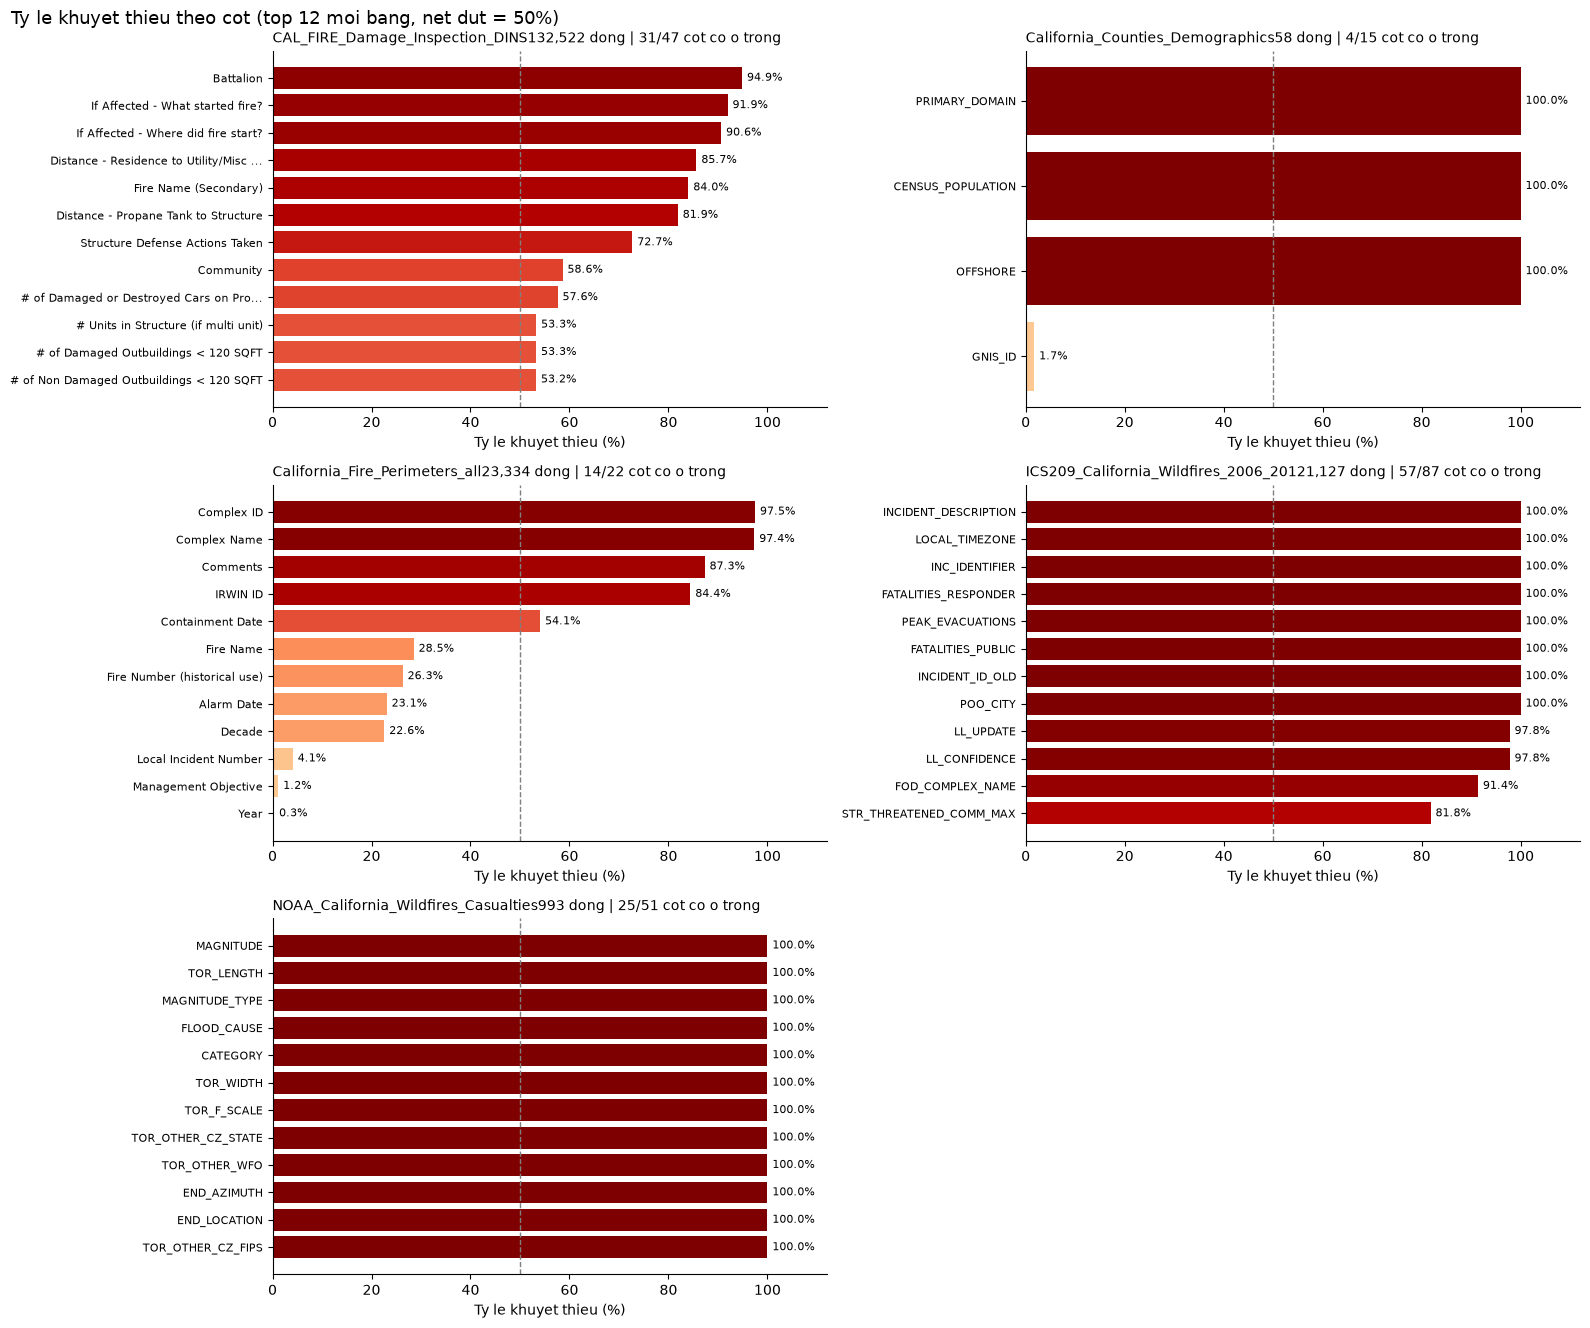

In [4]:
# Test 1: mac dinh - doc ca 5 file tho
fig = plot_missing_values()
plt.show()

[TV1 - EDA] Da luu bieu do khuyet thieu -> reports\figures\_test_missing_perimeters.png


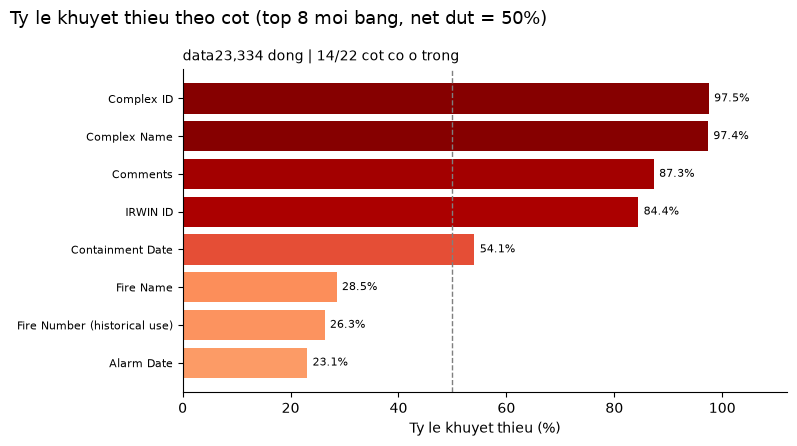

Complex ID                      97.5
Complex Name                    97.4
Comments                        87.3
IRWIN ID                        84.4
Containment Date                54.1
Fire Name                       28.5
Fire Number (historical use)    26.3
Alarm Date                      23.1
dtype: float64

In [5]:
# Test 2: truyen 1 DataFrame + doi chieu so lieu voi bang tinh tay
perimeters = pd.read_csv(RAW_DIR / "California_Fire_Perimeters_all.csv", encoding="utf-8-sig", low_memory=False)
fig = plot_missing_values(perimeters, output_path=Path("reports/figures/_test_missing_perimeters.png"), top_n=8)
plt.show()
(perimeters.isna().mean() * 100).round(1).sort_values(ascending=False).head(8)

## Test `plot_distributions` (eda_02)
Histogram + KDE tren thang log cho dien tich chay (`burned_area_ha`). NOAA chi dung cho thiet hai ve nguoi (xem eda_06).

In [ ]:
import numpy as np
import seaborn as sns


# Copy tu src/02_eda.py (khong import truc tiep duoc vi dong sys.stdout.reconfigure loi trong Jupyter)
def load_raw_data(raw_dir: Path = RAW_DIR) -> dict:
    perimeters = pd.read_csv(raw_dir / "California_Fire_Perimeters_all.csv", encoding="utf-8-sig", low_memory=False)
    noaa = pd.read_csv(raw_dir / "NOAA_California_Wildfires_Casualties.csv", encoding="utf-8-sig", low_memory=False)
    ics = pd.read_csv(raw_dir / "ICS209_California_Wildfires_2006_2012.csv", encoding="utf-8-sig", low_memory=False)
    perimeters["burned_area_ha"] = perimeters["GIS Calculated Acres"] * 0.404686
    return {"perimeters": perimeters, "noaa": noaa, "ics209": ics}


raw = load_raw_data()

In [ ]:
MEGAFIRE_HA = 100_000 * 0.404686  # sieu dam chay >= 100.000 acres (theo DEMO_SCRIPT.md)


def plot_distributions(df=None, output_path: Path = Path("reports/figures/eda_02_distributions.png")):
    """Ve bieu do phan phoi Histogram/KDE cua dien tich chay tren thang log."""
    # df: dict tra ve tu load_raw_data(); None -> tu doc
    data = df if df is not None else load_raw_data()
    perimeters = data["perimeters"]

    # Chi lay giai doan nghien cuu 2006-2025; thang log khong nhan gia tri <= 0
    area = perimeters.loc[perimeters["Year"].between(2006, 2025), "burned_area_ha"]
    area = area[area > 0]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(area, log_scale=True, bins=40, kde=True, color="#F16913", edgecolor="white", ax=ax)
    ax.axvline(area.median(), color="#7F7F7F", linestyle="--", linewidth=1)
    ax.text(area.median(), 0.97, f" trung vi {area.median():,.0f} ha", transform=ax.get_xaxis_transform(), va="top", fontsize=8)
    ax.axvline(MEGAFIRE_HA, color="#8C2D04", linestyle=":", linewidth=1.2)
    ax.text(MEGAFIRE_HA, 0.88, f" sieu dam chay\n >= {MEGAFIRE_HA:,.0f} ha", transform=ax.get_xaxis_transform(), va="top", fontsize=8, color="#8C2D04")
    ax.set_title(f"Dien tich chay (FRAP 2006-2025, n = {len(area):,} vu)", loc="left", fontsize=11)
    ax.set_xlabel("burned_area_ha (thang log)")
    ax.set_ylabel("So vu chay")
    ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle("Phan phoi lech phai manh -> can bien doi log1p truoc khi lam sach / mo hinh", fontsize=13, x=0.01, ha="left")
    fig.tight_layout()

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"[TV1 - EDA] Da luu bieu do phan phoi -> {output_path}")
    return fig

In [ ]:
# Test 1: dung du lieu da doc san
fig = plot_distributions(raw)
plt.show()

In [ ]:
# Test 2: kiem tra nhan xet "lech phai" bang so lieu - skewness truoc/sau log1p
area = raw["perimeters"].loc[raw["perimeters"]["Year"].between(2006, 2025), "burned_area_ha"]
pd.DataFrame({
    "n": [area.count()],
    "trung_vi": [area.median()],
    "max": [area.max()],
    "skew_goc": [area.skew()],
    "skew_log1p": [np.log1p(area).skew()],
}, index=["burned_area_ha"]).round(2)

## Test `plot_outlier_boxplots` (eda_03)
Boxplot so cong trinh bi pha huy moi vu chay (`structures_destroyed`): ICS-209 (2006-2012) + DINS (2013-2025).

In [ ]:
def build_structures_destroyed(data: dict) -> pd.DataFrame:
    """Gop so cong trinh bi pha huy theo tung vu chay tu ICS-209 va DINS."""
    ics = data["ics209"]
    ics_part = pd.DataFrame({
        "year": ics["START_YEAR"],
        "fire_name": ics["INCIDENT_NAME"].str.strip().str.upper(),
        "structures_destroyed": ics["STR_DESTROYED_TOTAL"],
        "source": "ICS-209 (2006-2012)",
    })

    # DINS: moi dong la 1 cong trinh -> dem so dong "Destroyed (>50%)" theo (nam, ten vu chay)
    dins = data["dins"] if "dins" in data else pd.read_csv(RAW_DIR / "CAL_FIRE_Damage_Inspection_DINS.csv", encoding="utf-8-sig", low_memory=False)
    destroyed = dins[dins["* Damage"] == "Destroyed (>50%)"]
    year = pd.to_datetime(destroyed["Incident Start Date"], format="%m/%d/%Y %I:%M:%S %p").dt.year
    dins_part = (
        destroyed.assign(year=year, fire_name=destroyed["* Incident Name"].str.strip().str.upper())
        .groupby(["year", "fire_name"]).size().rename("structures_destroyed").reset_index()
        .assign(source="DINS (2013-2025)")
    )

    combined = pd.concat([ics_part, dins_part], ignore_index=True)
    # Chi giu vu chay co pha huy >= 1 cong trinh (DINS von chi ghi nhan vu co thiet hai; thang log khong nhan 0)
    return combined[combined["structures_destroyed"] > 0]


structures = build_structures_destroyed(raw)
structures.groupby("source")["structures_destroyed"].describe().round(1)

In [ ]:
def plot_outlier_boxplots(df=None, output_path: Path = Path("reports/figures/eda_03_outliers_boxplot.png"), top_n: int = 3):
    """Ve bieu do hop (Boxplot) phat hien ngoai lai so cong trinh bi pha huy moi vu chay."""
    # df: DataFrame tu build_structures_destroyed(); None -> tu doc va gop
    data = df if df is not None else build_structures_destroyed(load_raw_data())
    palette = {"ICS-209 (2006-2012)": "#FDAE6B", "DINS (2013-2025)": "#F16913"}

    fig, ax = plt.subplots(figsize=(12, 5))
    # whis=1.5 tinh tren truc log -> nguong ngoai lai Tukey cho phan phoi log-normal
    sns.boxplot(data=data, x="structures_destroyed", y="source", hue="source", palette=palette,
                log_scale=True, whis=1.5, width=0.5, showfliers=False, legend=False, ax=ax)
    sns.stripplot(data=data, x="structures_destroyed", y="source", color="#8C2D04",
                  size=3, alpha=0.4, jitter=0.2, ax=ax)

    # Gan nhan top_n vu lon nhat MOI nguon; moi nhan 1 tang cao rieng de khong de len nhau
    order = list(palette)
    for y, source in enumerate(order):
        top = data[data["source"] == source].nlargest(top_n, "structures_destroyed")
        for k, (_, row) in enumerate(top.iterrows()):
            ax.annotate(f"{row['fire_name'].title()} {int(row['year'])}: {int(row['structures_destroyed']):,}",
                        xy=(row["structures_destroyed"], y), xytext=(0, 18 + 16 * k), textcoords="offset points",
                        ha="center", fontsize=8, arrowprops={"arrowstyle": "-", "color": "#7F7F7F", "lw": 0.8})

    counts = data["source"].value_counts()
    ax.set_yticks(range(len(order)), [f"{s}\nn = {counts.get(s, 0)} vu" for s in order])
    ax.set_xlabel("So cong trinh bi pha huy moi vu chay (thang log)")
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title("Cong trinh bi pha huy moi vu chay: phan lon vu chay < 40 nha, mot so it sieu tham hoa hang nghin nha",
                 loc="left", fontsize=12)
    fig.tight_layout()

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"[TV1 - EDA] Da luu Boxplot ngoai lai -> {output_path}")
    return fig

In [ ]:
# Test 1
fig = plot_outlier_boxplots(structures)
plt.show()

In [ ]:
# Test 2: dem ngoai lai theo nguong Tukey (1.5 IQR) tren thang goc va thang log
def tukey_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return int((s > q3 + 1.5 * (q3 - q1)).sum())

pd.DataFrame({
    "n_vu": structures.groupby("source")["structures_destroyed"].size(),
    "tong_nha": structures.groupby("source")["structures_destroyed"].sum(),
    "ngoai_lai_thang_goc": structures.groupby("source")["structures_destroyed"].apply(tukey_outliers),
    "ngoai_lai_thang_log": structures.groupby("source")["structures_destroyed"].apply(lambda s: tukey_outliers(np.log10(s))),
})